In [66]:
import numpy as np
from collections import Counter, defaultdict
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

Given a data point:

- Calculate its distance from all other data points
- Get the closest K points
- Regression: Get the average of their values
- Get the label with majority vote

In [88]:
class KNN:
    def __init__(self, k=3, scale=True, weighted=True):
        if not isinstance(k, int) or k <= 0:
            raise ValueError("k must be a positive integer.")

        self.k = k
        self.scale = scale
        self.weighted = weighted

        self.X_train = None
        self.y_train = None
        self.mean_ = None
        self.std_ = None
        self.classes_ = None

    def _validate_X_y(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        if X.ndim != 2:
            raise ValueError("X must be a 2D array with shape (n_samples, n_features).")
        if y.ndim != 1:
            raise ValueError("y must be a 1D array.")
        if len(X) != len(y):
            raise ValueError("X and y must have the same number of samples.")
        if len(X) == 0:
            raise ValueError("Training data cannot be empty.")
        if self.k > len(X):
            raise ValueError("k cannot be greater than the number of training samples.")
        if np.isnan(X).any():
            raise ValueError("X contains NaN values. Handle missing values before training.")

        return X, y

    def _validate_X(self, X):
        X = np.asarray(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        if X.ndim != 2:
            raise ValueError("X must be a 2D array with shape (n_samples, n_features).")
        if self.X_train is None:
            raise ValueError("The model must be fitted before calling predict or predict_proba.")
        if X.shape[1] != self.X_train.shape[1]:
            raise ValueError("X has a different number of features than the training data.")
        if np.isnan(X).any():
            raise ValueError("X contains NaN values. Handle missing values before prediction.")

        return X

    def _fit_standardization(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return (X - self.mean_) / self.std_

    def _transform_standardization(self, X):
        return (X - self.mean_) / self.std_

    def fit(self, X, y):
        X, y = self._validate_X_y(X, y)

        if self.scale:
            X = self._fit_standardization(X)

        self.X_train = X
        self.y_train = y
        self.classes_ = np.unique(y)

        return self

    def _compute_distances(self, x):
        return np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

    def _get_neighbors(self, x):
        distances = self._compute_distances(x)
        neighbor_indices = np.argsort(distances)[:self.k]
        neighbor_distances = distances[neighbor_indices]
        neighbor_labels = self.y_train[neighbor_indices]
        return neighbor_indices, neighbor_distances, neighbor_labels

    def _predict_one(self, x):
        neighbor_indices, neighbor_distances, neighbor_labels = self._get_neighbors(x)

        if self.weighted:
            class_scores = defaultdict(float)
            epsilon = 1e-10

            for label, distance in zip(neighbor_labels, neighbor_distances):
                class_scores[label] += 1.0 / (distance + epsilon)

            max_score = max(class_scores.values())
            tied_classes = [label for label, score in class_scores.items() if score == max_score]

            if len(tied_classes) == 1:
                return tied_classes[0]

            for idx in neighbor_indices:
                if self.y_train[idx] in tied_classes:
                    return self.y_train[idx]

        values, counts = np.unique(neighbor_labels, return_counts=True)
        max_count = counts.max()
        tied_classes = values[counts == max_count]

        if len(tied_classes) == 1:
            return tied_classes[0]

        for idx in neighbor_indices:
            if self.y_train[idx] in tied_classes:
                return self.y_train[idx]

    def predict(self, X):
        X = self._validate_X(X)

        if self.scale:
            X = self._transform_standardization(X)

        predictions = [self._predict_one(x) for x in X]
        return np.array(predictions)

    def predict_proba(self, X):
        X = self._validate_X(X)

        if self.scale:
            X = self._transform_standardization(X)

        probabilities = []
        epsilon = 1e-10

        for x in X:
            _, neighbor_distances, neighbor_labels = self._get_neighbors(x)
            class_scores = {label: 0.0 for label in self.classes_}

            if self.weighted:
                for label, distance in zip(neighbor_labels, neighbor_distances):
                    class_scores[label] += 1.0 / (distance + epsilon)
            else:
                for label in neighbor_labels:
                    class_scores[label] += 1.0

            total_score = sum(class_scores.values())
            probabilities.append([class_scores[label] / total_score for label in self.classes_])

        return np.array(probabilities)

    def score(self, X, y):
        y = np.asarray(y)
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

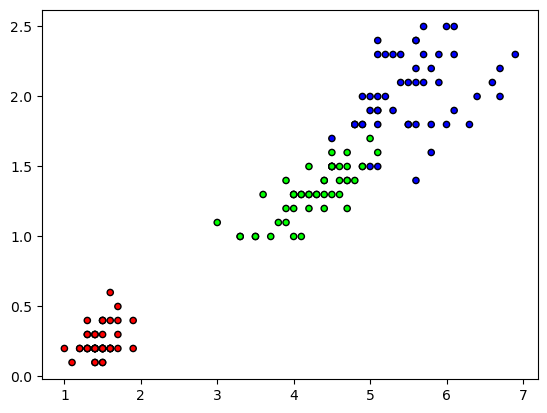

In [95]:
cmap = ListedColormap(['#FF0000','#00FF00','#0000FF'])

iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

plt.figure()
plt.scatter(X[:, 2], X[:, 3], c=y, cmap=cmap, edgecolor='k', s=20)

clf = KNN(k=5, scale=True, weighted=True)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

In [96]:
print(predictions)

[1 1 2 0 1 0 0 0 1 2 1 0 2 1 0 1 2 0 2 1 1 1 1 1 2 0 2 1 2 0]


In [97]:
acc = np.sum(predictions == y_test) / len(y_test)
print(acc)

1.0


In [98]:
acc = accuracy_score(y_test, predictions)
prec_macro = precision_score(y_test, predictions, average="macro")
rec_macro = recall_score(y_test, predictions, average="macro")
f1_macro = f1_score(y_test, predictions, average="macro")

print("Accuracy:", acc)
print("Precision (macro):", prec_macro)
print("Recall (macro):", rec_macro)
print("F1-score (macro):", f1_macro)

Accuracy: 1.0
Precision (macro): 1.0
Recall (macro): 1.0
F1-score (macro): 1.0


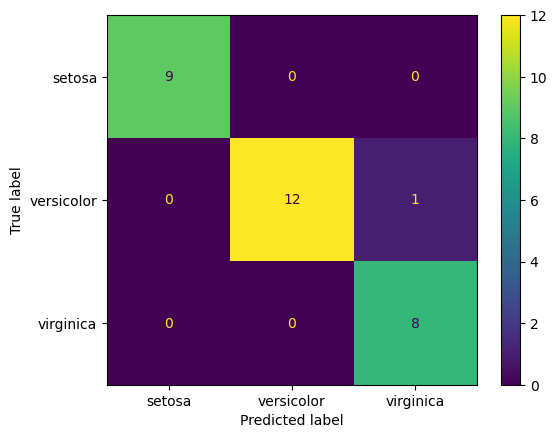

In [99]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)
disp.plot()
plt.show()

In [100]:
print("\nClassification report:")
print(classification_report(y_test, predictions))


Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         8

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

